**Нейронная сеть прямого распространения** (Feedforward Neural Network, FNN) — это базовый тип нейросети, где данные проходят только вперёд:

вход -> скрытые слои -> выход

Без циклов и обратных связей — сеть не “помнит” предыдущие состояния.

Сеть обучается на размеченных примерах: вход -> правильный класс

**Процесс**:
- Делает предсказание
- Считает ошибку 
- Через backpropagation вычисляет, как изменить веса
- Обновляет веса градиентным спуском
  
**Плюсы**
- Простая и универсальная архитектура
- Хорошо работает на табличных данных
- Подходит как базовая модель для классификации

**Минусы**
- Не учитывает порядок/временную структуру данных

Для задач классификации и регрессии в НС скрытые слои часто одинаковы. Разница обычно только в:
- последнем слое
- ф-ии активации
- ф-ии потерь
- метриках

Например, в НС для регресии последней функции активации обычно нет, а функции потерь - MSE / MAE

In [97]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

In [98]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/resale.csv", sep=",")
df.head()

,title,model_family,generation_number,is_pro,storage_options_gb,storage_gb_numeric,condition,price,wasPrice,price_discount_pct,available,sold,seller,itemLocation,us_state,lastUpdated
0,Apple iPhone 14 128gb RED color (Factory Unloc...,iPhone 14,14.0,False,128GB,128.0,Used,329.99,NaN,NaN,NaN,NaN,Seller 019,"Granada Hills, California, United States",CA,2026-01-02
1,Lot of 10 Apple iPhone 12 Pro 128GB Unlocked M...,iPhone 12 Pro,12.0,True,128GB,128.0,Used,3160.00,NaN,NaN,NaN,NaN,Seller 332,"Winter Park, Florida, United States",FL,2026-03-01
2,Apple iPhone 14 Pro MAX 128GB FULLY Unlocked,iPhone 14 Pro Max,14.0,True,128GB,128.0,Used,726.99,NaN,NaN,3.0,NaN,Seller 019,"Granada Hills, California, United States",CA,2025-12-12
3,Apple iPhone 14 Pro MAX 256gb Space black (Fac...,iPhone 14 Pro Max,14.0,True,256GB,256.0,Used,669.99,NaN,NaN,NaN,NaN,Seller 019,"Granada Hills, California, United States",CA,2025-12-12
4,Apple iPhone 14 Pro MAX 512gb Deep purple (Fac...,iPhone 14 Pro Max,14.0,True,512GB,512.0,Used,659.99,NaN,NaN,2.0,NaN,Seller 019,"Granada Hills, California, United States",CA,2026-03-10


In [99]:
def get_model_type(model_name):
    if pd.isna(model_name):
        return 'unknown'
    
    model_name = str(model_name).lower()
    
    if 'max' in model_name:
        return 'max'
    elif 'mini' in model_name:
        return 'mini'
    else:
        return 'regular'

In [100]:
# Блок с предварительной обработкой датасета

df.info()

data = df.copy()

data = data.drop(['wasPrice', 'price_discount_pct', 'itemLocation', 'title', 'lastUpdated', 'itemLocation', 'storage_options_gb'], axis=1)

value_counts = df['seller'].value_counts()
rare_sellers = value_counts[value_counts == 1].index
data['seller'] = data['seller'].replace(rare_sellers, 'small')

data['model_family'] = data['model_family'].apply(get_model_type)

le = LabelEncoder()
to_encode = ['us_state', 'seller', 'condition', 'model_family']
for col in to_encode:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

data['storage_gb_numeric'] = data['storage_gb_numeric'].fillna(0)
data['available'] = data['available'].fillna(1)
data['sold'] = data['sold'].fillna(0)

data.info()


<class 'pandas.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               2371 non-null   str    
 1   model_family        2371 non-null   str    
 2   generation_number   2371 non-null   float64
 3   is_pro              2371 non-null   bool   
 4   storage_options_gb  2168 non-null   str    
 5   storage_gb_numeric  2168 non-null   float64
 6   condition           2371 non-null   str    
 7   price               2371 non-null   float64
 8   wasPrice            134 non-null    float64
 9   price_discount_pct  134 non-null    float64
 10  available           1222 non-null   float64
 11  sold                912 non-null    float64
 12  seller              2371 non-null   str    
 13  itemLocation        2370 non-null   str    
 14  us_state            2370 non-null   str    
 15  lastUpdated         1956 non-null   str    
dtypes: bool(1), float

['model_family', 'generation_number', 'is_pro', 'storage_gb_numeric', 'condition', 'price', 'available', 'sold', 'seller', 'us_state']


<Axes: >

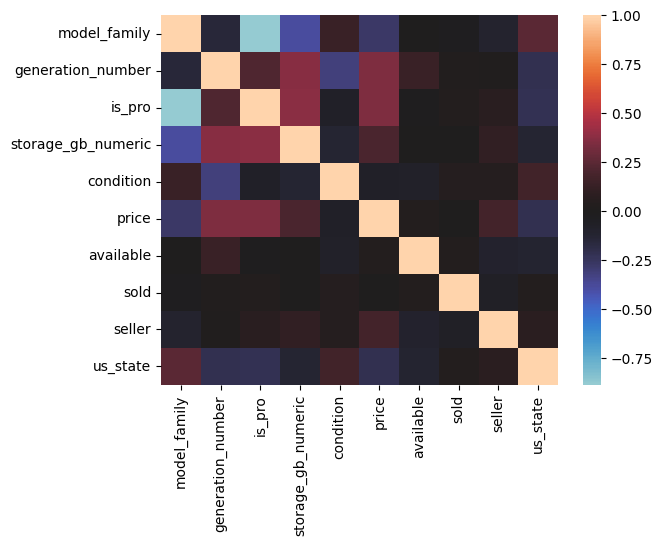

In [101]:
#блок с тепловой картой 

numeric_cols = data.select_dtypes(include=['int64', 'float64', 'bool']).columns.to_list()

print(numeric_cols)

sns.heatmap(data[numeric_cols].corr(), center=0)

In [102]:
#Блок с обучением модели

# Признаки (X) и целевая переменная (y)

X = data.drop('price', axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6769
)

In [103]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(16,8),
        activation='relu',
        learning_rate_init=0.001,
        solver='adam',
        max_iter=5000,
        random_state=6769
    ))
])

regressor = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

regressor.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...state=6769))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",StandardScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'


In [104]:
# Предсказание
y_pred = regressor.predict(X_test)

In [105]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

MAE: 154.78291119242306
MSE: 95597.25180301748
R2: 0.5525052425159582
